<h1> Bit Flip Error Code

In [1]:
from qiskit import __version__
assert __version__ >= "2.0.0", "Qiskit version must be at least 2.0.0"
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

import matplotlib.pyplot as plt

plt.style.use('dark_background')

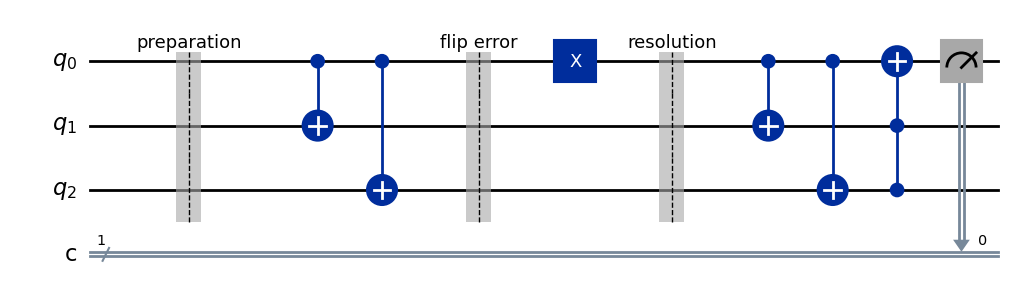

In [2]:
def bit_flip_circuit():

    qr = QuantumRegister(3, 'q')
    cr = ClassicalRegister(1, 'c')

    qc = QuantumCircuit(qr, cr)

    qc.barrier(label='preparation')
    qc.cx(qr[0], qr[1])
    qc.cx(qr[0], qr[2])

    qc.barrier(label='flip error')

    qc.x(qr[0])

    qc.barrier(label='resolution')

    qc.cx(qr[0], qr[1])
    qc.cx(qr[0], qr[2])
    qc.ccx(qr[1], qr[2], qr[0])

    # qc.measure(qr, cr)
    qc.measure(qr[0], cr[0])
    
    return qc

bit_flip_circuit().draw(output='mpl')

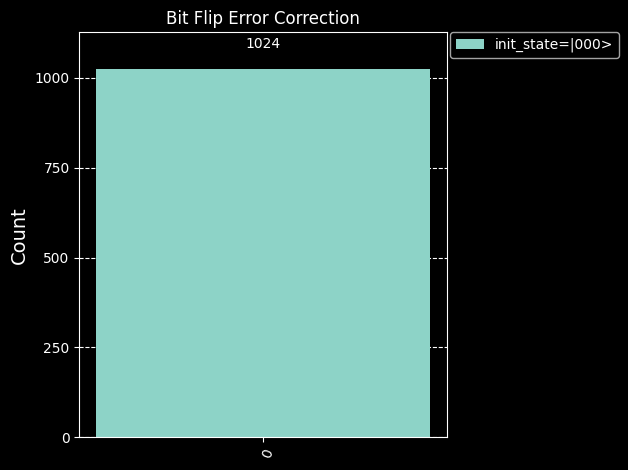

In [ ]:
sim = AerSimulator(method='statevector')

qc_tr = transpile(bit_flip_circuit(), sim)
result = sim.run(qc_tr).result()
counts = result.get_counts()

plot_histogram(counts, legend=['init_state=|000>'], title='Bit Flip Error Correction')

<h2> Changing Error Position to Ancilla Qubits

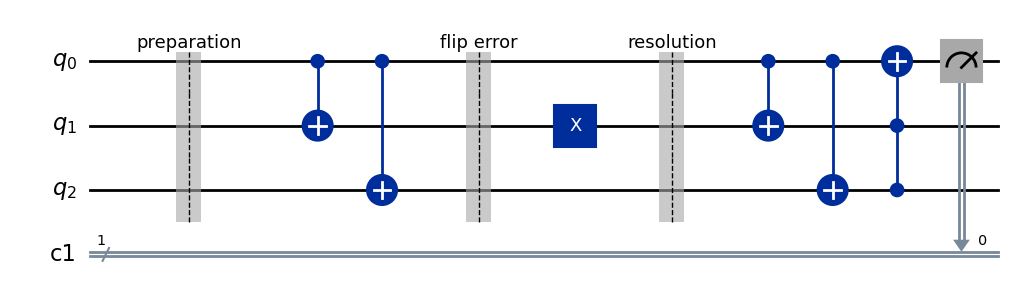

In [4]:
def bit_flip_circuit_2(i):

    qr = QuantumRegister(3, 'q')
    cr = ClassicalRegister(1, 'c1')

    qc = QuantumCircuit(qr, cr)

    qc.barrier(label='preparation')
    qc.cx(qr[0], qr[1])
    qc.cx(qr[0], qr[2])

    qc.barrier(label='flip error')

    qc.x(qr[i])

    qc.barrier(label='resolution')

    qc.cx(qr[0], qr[1])
    qc.cx(qr[0], qr[2])
    qc.ccx(qr[1], qr[2], qr[0])

    # qc.measure(qr, cr)
    qc.measure(qr[0], cr[0])
    
    return qc

bit_flip_circuit_2(1).draw(output='mpl')

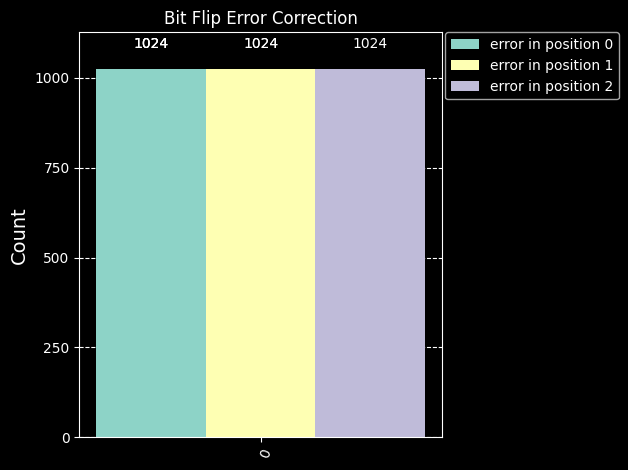

In [5]:
sim = AerSimulator(method='statevector')

qc_tr = transpile([bit_flip_circuit_2(i) for i in range(3)], sim)
result = sim.run(qc_tr).result()
counts = result.get_counts()

plot_histogram(counts, legend=[f'error in position {i}' for i in range(3)], title='Bit Flip Error Correction')

<p1> IBM_RUNTIME

In [6]:
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit.transpiler import generate_preset_pass_manager
 
service = QiskitRuntimeService(channel='ibm_quantum')
backend = service.least_busy(min_num_qubits=3, simulator=False)
pm = generate_preset_pass_manager(optimization_level=1, backend=backend)

In [7]:
qcs = [bit_flip_circuit_2(i) for i in range(3)]
transpiled_qcs = [pm.run(i) for i in qcs]

In [9]:
sampler = Sampler(mode=backend)

if False:
    job = sampler.run(transpiled_qcs, shots=1000)
    print(f"Job ID: {job.job_id()}")

In [20]:
job_id = 'd143xken2txg008jvagg'
# job_id = 'd144dne5z6q00087bvhg'
# job_id = 'd14qga9qf56g0081ve70'

job = service.job(job_id)
result = job.result()

for idx, res in enumerate(result):
    print(f"Circuit {idx} result:", res.data)

Circuit 0 result: DataBin(c=BitArray(<shape=(), num_shots=8192, num_bits=1>))
Circuit 1 result: DataBin(c=BitArray(<shape=(), num_shots=8192, num_bits=1>))
Circuit 2 result: DataBin(c=BitArray(<shape=(), num_shots=8192, num_bits=1>))


In [23]:
from qiskit_aer.noise import NoiseModel, pauli_error

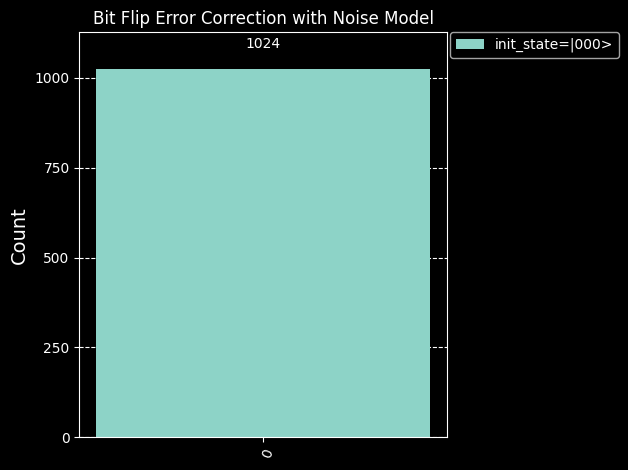

In [24]:
noise_model = NoiseModel()

bit_flip_err = pauli_error([('X', 0.1), ('I', 0.9)])
noise_model.add_quantum_error(bit_flip_err, 'X', [0])

aer_sim = AerSimulator(noise_model=noise_model, method='statevector')
qc_tr = transpile(bit_flip_circuit(), aer_sim)
result = aer_sim.run(qc_tr).result()
counts = result.get_counts()
plot_histogram(counts, legend=['init_state=|000>'], title='Bit Flip Error Correction with Noise Model')

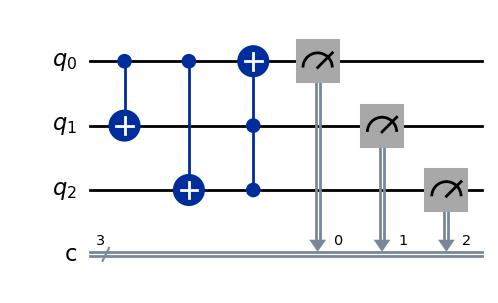

In [25]:
qc = QuantumCircuit(3,3)
qc.cx(0, 1)
qc.cx(0, 2)
qc.ccx(1, 2, 0)
qc.measure([0, 1, 2], [0, 1, 2])
qc.draw(output='mpl')